# Optuna Parameter Calibration: Return vs Dynamic Risk Control

This notebook reads a completed `trial_metrics.csv` generated by `scripts.optimization.optuna_calibration`. It does **not** rerun the expensive portfolio simulations. The analysis compares a maximum-return policy with a return-constrained risk-control policy and studies stable parameter ranges.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from scripts.optimization.analysis import (
    add_policy_scores, build_parameter_range_summary, choose_policy_trials,
    extract_pareto_front, policy_comparison_table,
)

TRIAL_METRICS = Path('results/calibration/advanced_smart_bayesian_risk_return/trial_metrics.csv')
assert TRIAL_METRICS.exists(), f'Run the Optuna calibration first: {TRIAL_METRICS}'
trials = add_policy_scores(pd.read_csv(TRIAL_METRICS))
completed = trials[trials['status'].astype(str).str.upper().eq('COMPLETE')].copy()
completed.head()


,trial_number,status,datetime_start,datetime_complete,duration_seconds,param_optimizer.0.max_weight,param_optimizer.0.turnover_penalty,param_optimizer.0.confidence_level,param_optimizer.0.cvar_budget_mult,param_model.prior_strength,...,sharpe_ratio,sortino_ratio,turnover,win_rate,objective_0,objective_1,objective_2,objective_3,return_policy_score,risk_control_score
0,0,COMPLETE,2026-09-02 19:00:42.354905,2026-09-02 19:08:18.014310,455.659405,0.10,0.006978,0.900,0.75,126.0,...,1.156141,2.240414,0.01,0.68,0.262092,0.202923,0.123009,0.090225,0.565296,-0.032077
1,1,COMPLETE,2026-09-02 19:08:18.075227,2026-09-02 19:15:51.067131,452.991904,0.09,0.002142,0.975,0.90,63.0,...,1.213143,2.373180,0.01,0.68,0.261093,0.190896,0.110555,0.084405,0.623746,0.149292
2,2,COMPLETE,2026-09-02 19:15:51.119038,2026-09-02 19:23:20.747736,449.628698,0.06,0.006943,0.900,1.10,63.0,...,1.385580,3.012784,0.01,0.72,0.220303,0.136860,0.069614,0.057205,0.114173,0.660239
3,3,COMPLETE,2026-09-02 19:23:20.797289,2026-09-02 19:30:39.933812,439.136523,0.12,0.000835,0.900,1.05,126.0,...,1.222656,2.230179,0.01,0.80,0.141564,0.096154,0.072577,0.044711,-1.591577,0.122283
4,4,COMPLETE,2026-09-02 19:30:39.996013,2026-09-02 19:38:01.181614,441.185601,0.09,0.002251,0.990,1.15,42.0,...,1.168078,2.243504,0.01,0.76,0.134098,0.094856,0.064323,0.043408,-1.802898,0.050499


## 1. Select the two policies

The maximum-return configuration answers the profit-seeking question. The risk-control configuration must first pass a return floor, then maximizes a robust utility that rewards Sharpe, Sortino, PSR and DSR while penalizing volatility, drawdown, CVaR and turnover.

In [2]:
selected = choose_policy_trials(
    completed, return_floor_quantile=0.35, minimum_annual_return=0.05, minimum_dsr=0.50
)
comparison = policy_comparison_table(completed, selected)
comparison


,policy,trial_number,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,cvar_95,downside_deviation,psr,dsr,turnover,return_policy_score,risk_control_score,parameters
0,max_return,22,0.277135,0.185271,1.313352,2.822778,-0.098217,-0.074346,0.091093,0.962914,0.645436,0.01,1.061724,0.502934,"{""backtest_engine.degradation_penalty"": 0.55, ..."
1,risk_control,49,0.266670,0.160889,1.435435,3.254797,-0.084181,-0.057111,0.075787,0.974509,0.728221,0.01,1.062838,0.861100,"{""backtest_engine.degradation_penalty"": 0.55, ..."


## 2. Return-risk frontier

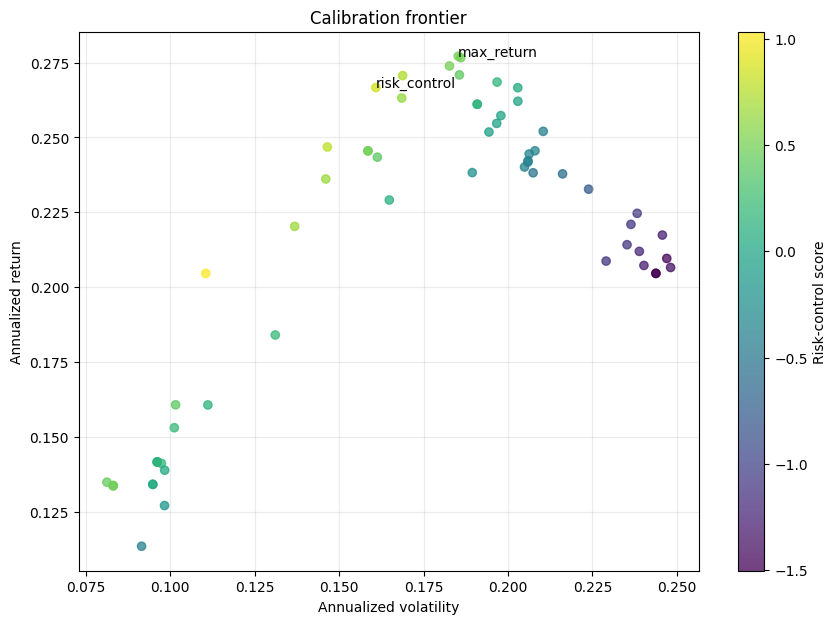

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    completed['annualized_volatility'], completed['annualized_return'],
    c=completed['risk_control_score'], cmap='viridis', alpha=0.75
)
for label, row in selected.items():
    ax.annotate(label, (row['annualized_volatility'], row['annualized_return']))
ax.set_xlabel('Annualized volatility')
ax.set_ylabel('Annualized return')
ax.set_title('Calibration frontier')
ax.grid(alpha=0.25)
fig.colorbar(scatter, ax=ax, label='Risk-control score')
plt.show()


## 3. Parameter ranges and metric response

In [4]:
ranges = build_parameter_range_summary(completed, max_bins=6, top_fraction=0.20)
ranges.head(20)


,parameter,range,n_trials,top_risk_control_share,median_annualized_return,mean_annualized_return,q25_annualized_return,q75_annualized_return,median_annualized_volatility,mean_annualized_volatility,...,q25_psr,q75_psr,median_dsr,mean_dsr,q25_dsr,q75_dsr,median_risk_control_score,mean_risk_control_score,q25_risk_control_score,q75_risk_control_score
0,backtest_engine.degradation_penalty,"(-0.001, 0.05]",12,0.000000,0.215765,0.208502,0.190222,0.244601,0.201904,0.183103,...,0.875576,0.943172,0.540459,0.524682,0.415026,0.587787,-0.196366,-0.345304,-1.106493,0.089907
1,backtest_engine.degradation_penalty,"(0.05, 0.367]",8,0.000000,0.151092,0.168422,0.141564,0.189636,0.104762,0.137639,...,0.926598,0.939239,0.572177,0.538046,0.520495,0.583758,0.122283,-0.179038,-0.170718,0.123146
2,backtest_engine.degradation_penalty,"(0.367, 0.55]",24,0.250000,0.241324,0.219411,0.191688,0.267127,0.185443,0.172352,...,0.914554,0.959933,0.576074,0.541414,0.509785,0.634848,0.128865,-0.094697,-0.387168,0.425761
3,backtest_engine.degradation_penalty,"(0.55, 0.7]",9,0.555556,0.237826,0.233713,0.224645,0.245504,0.158557,0.170479,...,0.923597,0.965030,0.662898,0.611262,0.520102,0.679709,0.492025,0.193125,-0.333124,0.652199
4,backtest_engine.degradation_penalty,"(0.7, 0.75]",7,0.142857,0.240113,0.235978,0.229603,0.262623,0.202907,0.186674,...,0.921591,0.952766,0.568947,0.553159,0.526077,0.579484,-0.032077,-0.097558,-0.308738,0.208653
5,backtest_engine.stability_weight,"(-0.001, 0.2]",21,0.142857,0.224645,0.215184,0.153004,0.261093,0.190896,0.167796,...,0.923597,0.944840,0.576542,0.564192,0.520102,0.601752,0.122283,-0.041872,-0.333124,0.170135
6,backtest_engine.stability_weight,"(0.2, 0.4]",13,0.307692,0.237826,0.232074,0.211933,0.263153,0.206274,0.199439,...,0.873796,0.961835,0.508855,0.532054,0.416105,0.652665,-0.370687,-0.317205,-1.108244,0.501484
7,backtest_engine.stability_weight,"(0.4, 0.7]",18,0.166667,0.207076,0.199241,0.140729,0.244981,0.158557,0.155746,...,0.926685,0.959543,0.563292,0.542677,0.535896,0.652032,0.088116,-0.066931,-0.135946,0.451731
8,backtest_engine.stability_weight,"(0.7, 1.0]",8,0.250000,0.233639,0.218545,0.206615,0.248112,0.166841,0.169496,...,0.909357,0.950488,0.556501,0.554380,0.479245,0.625631,-0.137853,-0.073219,-0.429009,0.334183
9,model.mom_tilt,"(-0.001, 0.05]",21,0.190476,0.141564,0.162405,0.134098,0.183997,0.098327,0.107679,...,0.937857,0.959645,0.583758,0.600583,0.560596,0.654030,0.170135,0.269308,0.108437,0.470778


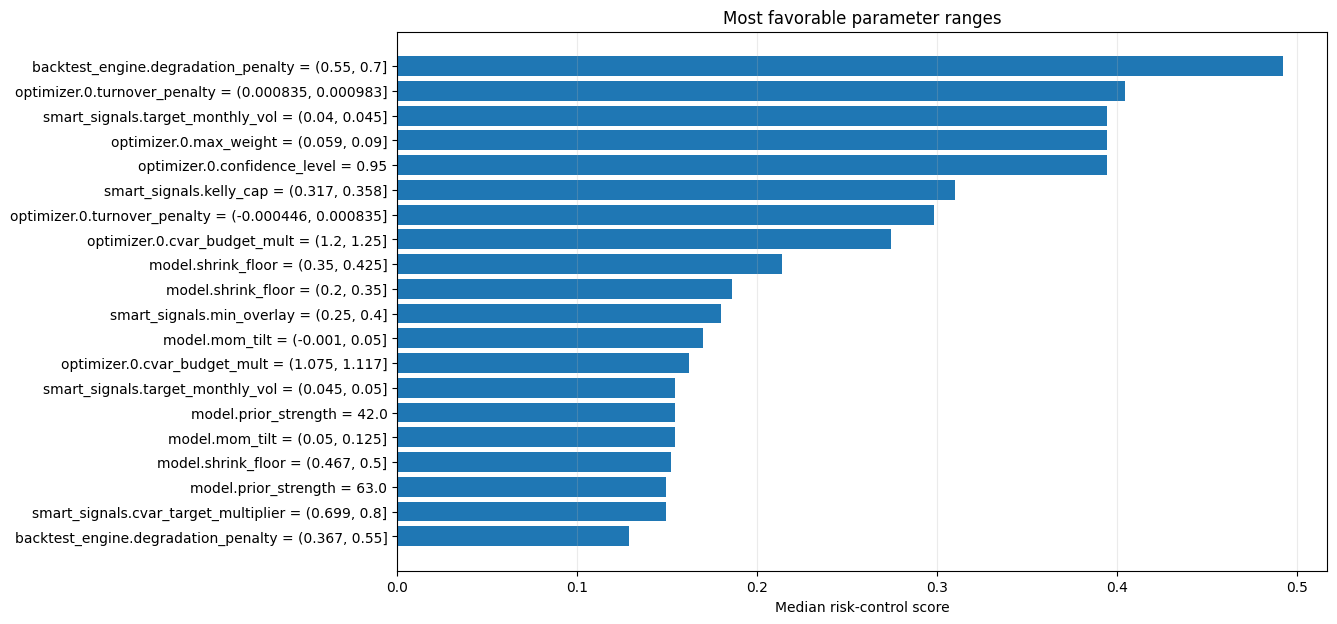

In [5]:
metric = 'median_risk_control_score'
top_ranges = ranges.sort_values(metric, ascending=False).head(20)
fig, ax = plt.subplots(figsize=(12, 7))
labels = top_ranges['parameter'] + ' = ' + top_ranges['range']
ax.barh(labels[::-1], top_ranges[metric][::-1])
ax.set_xlabel('Median risk-control score')
ax.set_title('Most favorable parameter ranges')
ax.grid(axis='x', alpha=0.25)
plt.show()


## 4. Pareto-efficient configurations

In [6]:
pareto = extract_pareto_front(completed)
pareto[[c for c in ['trial_number','annualized_return','annualized_volatility','max_drawdown','cvar_95','dsr'] if c in pareto]].head(20)


,trial_number,annualized_return,annualized_volatility,max_drawdown,cvar_95,dsr
0,22,0.277135,0.185271,-0.098217,-0.074346,0.645436
1,54,0.273887,0.182685,-0.098201,-0.073342,0.652665
2,52,0.270672,0.168818,-0.091394,-0.063550,0.695689
3,49,0.266670,0.160889,-0.084181,-0.057111,0.728221
4,20,0.246804,0.146525,-0.089430,-0.056268,0.716098
5,37,0.236121,0.146071,-0.079467,-0.060975,0.690329
6,2,0.220303,0.136860,-0.069614,-0.057205,0.679709
7,47,0.204564,0.110517,-0.051725,-0.042485,0.750871
8,58,0.160668,0.101608,-0.075367,-0.039649,0.582425
9,45,0.153004,0.101212,-0.078744,-0.043299,0.563289


## Interpretation checklist

A publishable calibration result should show: (i) a stable region rather than one isolated trial, (ii) a risk-control configuration that still clears the return floor, (iii) positive out-of-sample PSR/DSR evidence, and (iv) similar conclusions across adjacent parameter bins.